In [1]:
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_device", jax.devices()[1])

import numpy as np
import matplotlib.pyplot as plt
import jax
from tqdm.auto import tqdm
plt.style.use("ggplot")

from importlib import reload
import KernelTools
reload(KernelTools)
from KernelTools import *
from EquationModel import OperatorModel,OperatorPDEModel,build_batched_jac_func,InducedOperatorModel
from EquationModel import CholInducedRKHS
from evaluation_metrics import compute_results    
from data_utils import MinMaxScaler
from evaluation_metrics import get_nrmse

from Kernels import log1pexp,inv_log1pexp
from Kernels import (
    get_centered_scaled_poly_kernel,
    get_anisotropic_gaussianRBF,
    fit_kernel_params
)
from functools import partial

import Optimizers
import importlib
importlib.reload(Optimizers)
from Optimizers import CholeskyLM,SVD_LM,SketchedLM
import scipy


import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from scipy.sparse.linalg import spsolve,factorized
from scipy.sparse import identity,eye_array,csc_array,diags_array
from tqdm.auto import tqdm


from parabolic_data_utils import (
    build_burgers_data,build_tx_grid,
    build_tx_grid_chebyshev,setup_problem_data
)

from scipy.interpolate import RectBivariateSpline

from Optimizers import LMParams


In [2]:
# coeffs of Burgers eqn
kappa = 0.001

def get_ss_step(half_op1,op2):
        def strang_split_timestep(u):
            return half_op1(op2(half_op1(u)))
        return strang_split_timestep

def get_RD_solver(f,kappa,k = 1e-4,n = 1000):
    h = 1/(n+1)

    L = csc_array(diags_array([np.ones(n-1),-2 * np.ones(n),np.ones(n-1)],offsets = [-1,0,1]))
    L[0,-1] = 1
    L[-1,0] = 1
    L = L/(h**2)
    D = csc_array(diags_array([-np.ones(n-1),np.ones(n-1)],offsets = [-1,1]))
    D[0,-1] = -1
    D[-1,0] = 1
    D = D/(2*h)

    xgrid = np.linspace(0,1,n+1)
    def heat_step(k,kappa,n):
        B = L * kappa * k
        I = eye_array(n)
        L1 = I - B/4
        R1 = I + B/4
        L2 = I - B/3
        L1_solve = factorized(csc_array(L1))
        L2_solve = factorized(csc_array(L2))

        def trbdf2_heat(u):
            #u1 = spsolve(L1,R1@u)
            #spsolve(L2,(1/3) * (4 * u1 - u))
            u1 = L1_solve(R1@u)
            return L2_solve((1/3) * (4 * u1 - u))
        return trbdf2_heat

    def rk2_reaction(k):
        def rk2_step(u):
            u1 = u + (k/2)* f(u)
            return u + k * f(u1)
        return rk2_step
    
    half_heat = heat_step(k = k/2,kappa=kappa,n=n)
    reaction = rk2_reaction(k = k)
    RD_split_step = get_ss_step(half_heat,reaction)

    def solve_RD(u0,final_t = 1.):
        num_timesteps = final_t//k
        u_vals = [u0]
        u = u0
        for i in tqdm(range(int(num_timesteps))):
            u = RD_split_step(u)
            u_vals+=[u]
        return np.array(u_vals),np.arange(0,final_t,k)
    return xgrid,solve_RD

In [62]:
# IC
def func_u0(x):
    u0 = (np.sin(2 * np.pi*x) + 0.4 * np.cos(4*np.pi*x - 0.3))**2
    return u0
# solve Burgers eqn                            

def rd_func(x):
    result = 2*x*(1-x)
    return result

true_kappa = 2e-3
grid,solver = get_RD_solver(rd_func,kappa = true_kappa)
u0 = func_u0(grid)[-1]

sols,tvals = solver(func_u0(grid[:-1]))
sols = np.hstack([sols,sols[:,:1]])
interp = RectBivariateSpline(tvals,grid,sols)

def u_true_function(x):
    return interp(x[:,0],x[:,1],grid = False)

def ut_true_function(x):
    ut_interp = interp.partial_derivative(1,0)
    return ut_interp(x[:,0],x[:,1],grid = False)

/home/alexh/miniconda3/envs/kernel_eq/lib/python3.13/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_array is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


  0%|          | 0/9999 [00:00<?, ?it/s]

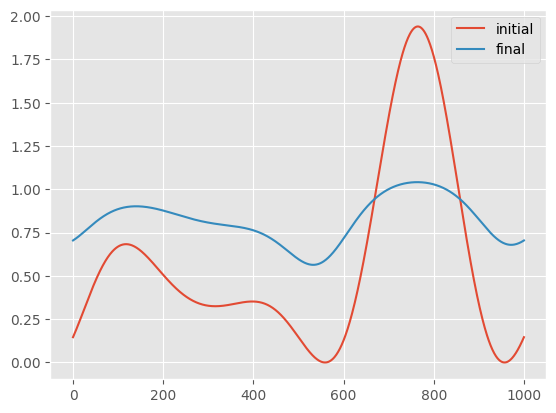

In [10]:
plt.plot(sols[0],label = 'initial')
plt.plot(sols[-1],label = 'final')
plt.legend()

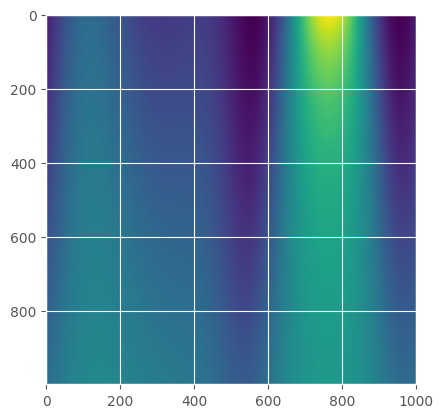

In [11]:
plt.imshow(sols[::10,:])

In [12]:
# size of coll grid
num_grid_x, num_grid_t = 31, 26

# get interior and bdry pts of coll grid
tx_int,tx_bdy = build_tx_grid_chebyshev([0,1],[0,1],
                                        num_grid_t,
                                        num_grid_x,
                                        alpha = 0.5
)

# coll grid and obs grid
seed = 55
n_obs = 60
tx_all, tx_obs = setup_problem_data(tx_int,
                                    tx_bdy,
                                    n_obs,
                                    jax.random.PRNGKey(seed),
                                    times_to_observe = (0,)
)

# u vals at coll grid
u_all = u_true_function(tx_all)

# u vals at obs grid
u_obs = u_true_function(tx_obs)

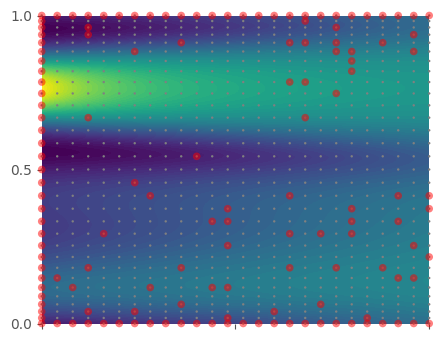

In [13]:
# fine grid
num_fine_grid = 300
t_fine, x_fine = jnp.meshgrid(jnp.linspace(0,1,num_fine_grid),jnp.linspace(0,1,num_fine_grid))
tx_fine = jnp.vstack([t_fine.flatten(),x_fine.flatten()]).T
# u vals at fine grid
u_true = u_true_function(tx_fine)

# u_true plot
plt.figure(figsize=(5,4))
plt.tricontourf(*tx_fine.T, u_true,
                levels= 70)# coll grid

plt.scatter(*tx_all.T,
            c='gray',
            s = 3,
            clip_on =False, 
            edgecolors = 'none')
# obs grid
plt.scatter(*tx_obs.T,
            c='red', 
            s = 30, 
            alpha = 0.5,
            clip_on =False,
            edgecolors = 'none')

# fig settings
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.locator_params(nbins=3)
plt.gca().set_xticklabels([])
plt.gca().set_xticklabels([]) 
plt.show()

In [19]:
from KernelTools import eval_k,dx_k,dt_k,dxx_k
from Kernels import get_gaussianRBF,fit_kernel_params
# u basis ops
u_operators = (eval_k,dx_k,dt_k)
# L ops
feature_operators = (eval_k,dxx_k)

# u kernel that also depends on params
def periodic_transform(x,period = 1.):
    return jnp.hstack([jnp.sin(x*(2*jnp.pi/period)),jnp.cos(x*(2*jnp.pi/period))])/(period * 2*jnp.pi)

t_lengthscale = 0.1
x_lengthscale = 0.05
def k_u(x,y):
    return (
        get_gaussianRBF(t_lengthscale)(x[0],y[0]) * 
        get_gaussianRBF(x_lengthscale)(periodic_transform(x[1]),periodic_transform(y[1]))
                                         )

# u RKHS
u_model = CholInducedRKHS(tx_all,
                          u_operators,
                          k_u,
                          nugget_size = 1e-8
)
# u fitted params
u_params_init = u_model.get_fitted_params(tx_obs,u_obs)
# L's at u
grid_features_init = (
    (u_model.evaluate_operators(feature_operators,tx_int,u_params_init))
    .reshape(
            len(tx_int),
            len(feature_operators),
            order = 'F'
        )
)

# P kernel
rbf_P = get_gaussianRBF(0.2)
@vectorize_kfunc
def k_P(x,y):
    return rbf_P(x[2],y[2]) + x[3]*y[3]
# P RKHS
P_model = OperatorModel(k_P)

# u and P object
EqnModel = OperatorPDEModel(P_model,
                            (u_model,),
                            (tx_obs,),
                            (u_obs,),
                            (tx_int,),
                            feature_operators,
                            rhs_operator=dt_k,
                            datafit_weight = 20.
)

In [21]:
params_init = jnp.hstack([u_params_init,jnp.zeros(len(grid_features_init))])

In [69]:
# options LM
optparams = LMParams(max_iter = 1001,print_every=250)
# initial params for LM
params_init = jnp.hstack([u_params_init,jnp.zeros(len(grid_features_init))])
# run LM
params,convergence_data = CholeskyLM(params_init.copy(),
                                     EqnModel,
                                     beta = 1e-11,
                                     optParams = optparams
)
# options SVD LM
svdparams = LMParams(max_iter = 2501,print_every=250)
params_adjusted,refine_convergence_data = SVD_LM(params,
                                                 EqnModel,
                                                 beta = 1e-11,
                                                 optParams = svdparams)

  0%|          | 0/1001 [00:00<?, ?it/s]

Iteration 0, loss = 1.812, gradnorm = 4.698e+04, alpha = 15.19, improvement_ratio = 0.3936
Iteration 1, loss = 1.606, gradnorm = 1.101e+05, alpha = 15.19, improvement_ratio = 0.5997
Iteration 2, loss = 1.308, gradnorm = 1.018e+05, alpha = 12.66, improvement_ratio = 0.98
Iteration 3, loss = 1.176, gradnorm = 1.885e+03, alpha = 10.55, improvement_ratio = 0.8117
Iteration 4, loss = 0.9989, gradnorm = 4.564e+04, alpha = 8.789, improvement_ratio = 0.9483
Iteration 5, loss = 0.9598, gradnorm = 2.496e+04, alpha = 8.789, improvement_ratio = 0.2462
Iteration 250, loss = 0.03738, gradnorm = 2.588e+03, alpha = 14.54, improvement_ratio = 0.6898
Iteration 500, loss = 0.00523, gradnorm = 1.068e+03, alpha = 6.338, improvement_ratio = 0.5663
Iteration 750, loss = 0.002563, gradnorm = 407.7, alpha = 6.338, improvement_ratio = 0.7231
Iteration 1000, loss = 0.001491, gradnorm = 438.1, alpha = 4.402, improvement_ratio = 0.5798


  0%|          | 0/2501 [00:00<?, ?it/s]

Iteration 0, loss = 0.001478, gradnorm = 433.0, alpha = 10.12, improvement_ratio = 0.7415
Iteration 1, loss = 0.001466, gradnorm = 584.5, alpha = 10.12, improvement_ratio = 0.7299
Iteration 2, loss = 0.001455, gradnorm = 591.8, alpha = 10.12, improvement_ratio = 0.724
Iteration 3, loss = 0.001445, gradnorm = 570.3, alpha = 10.12, improvement_ratio = 0.7354
Iteration 4, loss = 0.001435, gradnorm = 529.0, alpha = 10.12, improvement_ratio = 0.7593
Iteration 5, loss = 0.001427, gradnorm = 475.3, alpha = 10.12, improvement_ratio = 0.7902
Iteration 250, loss = 0.0001856, gradnorm = 404.6, alpha = 0.6716, improvement_ratio = 0.2303
Iteration 500, loss = 9.974e-05, gradnorm = 155.6, alpha = 0.6716, improvement_ratio = 0.3451
Iteration 750, loss = 6.803e-05, gradnorm = 58.88, alpha = 0.6716, improvement_ratio = 0.6463
Iteration 1000, loss = 4.951e-05, gradnorm = 33.42, alpha = 0.5597, improvement_ratio = 0.7975
Iteration 1250, loss = 3.291e-05, gradnorm = 34.96, alpha = 0.2699, improvement_rati

,NRMSE,NMAE
1 Step,0.030021,0.007698
2 Step,0.437328,0.267139


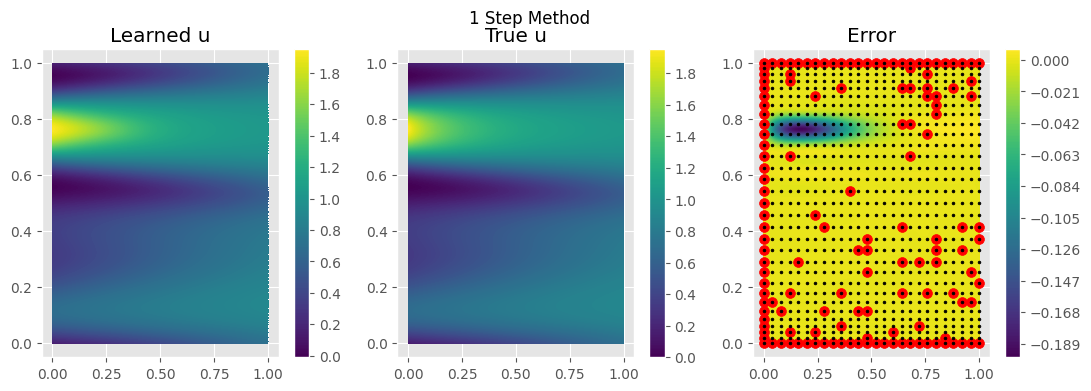

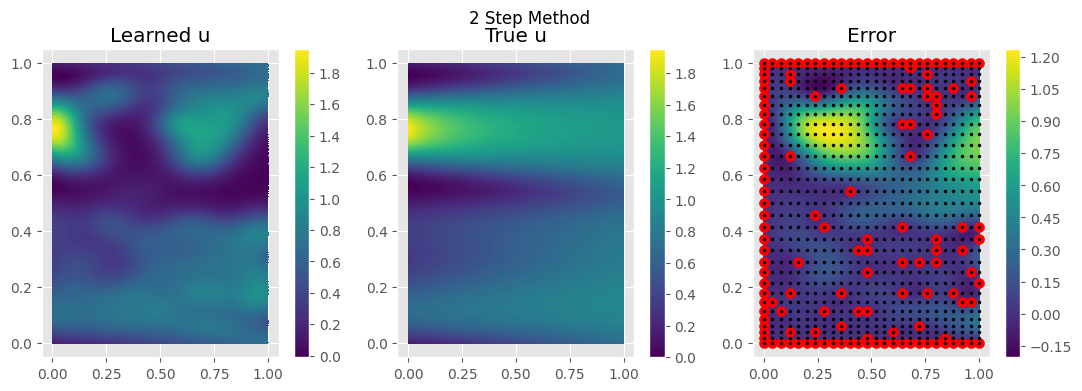

In [70]:
from evaluation_metrics import get_nrmse,get_nmae,compute_results
from plotting import plot_compare_error

u_sol = params_adjusted[:u_model.num_params]
P_sol = params_adjusted[u_model.num_params:]


num_fine_grid = 200
t_fine,x_fine = np.meshgrid(np.linspace(0,1.,num_fine_grid),np.linspace(0,1,num_fine_grid))
tx_grid_fine = np.vstack([t_fine.flatten(),x_fine.flatten()]).T


u_eval_fine =u_model.point_evaluate(tx_grid_fine,u_sol)
u_true_fine = u_true_function(tx_grid_fine)

display(compute_results(
    u_true_fine,
    {
        "1 Step":u_eval_fine,
        "2 Step":u_model.point_evaluate(tx_grid_fine,u_params_init),
    },
    {"NRMSE":get_nrmse,"NMAE":get_nmae}
))

plot_compare_error(
    tx_grid_fine,tx_all,tx_obs,lambda x:u_model.point_evaluate(x,u_sol),u_true_function,title= "1 Step Method"
)

plot_compare_error(
    tx_grid_fine,tx_all,tx_obs,lambda x:u_model.point_evaluate(x,u_params_init),u_true_function,title = "2 Step Method"
)

Estimated kappa:  0.002004138788583576
True kappa:  0.002


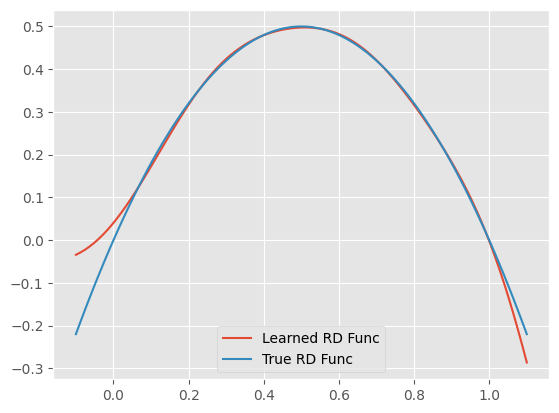

In [72]:
final_anchors = EqnModel.single_eqn_features(
    u_model,
    u_sol,
    EqnModel.collocation_points[0]
    )

extract_kappa = jnp.vstack([jnp.zeros(2),jnp.zeros(2),0.5 * jnp.ones(2),jnp.array([0.,1])]).T

lin_preds = P_model.predict_new(extract_kappa,final_anchors,P_sol)
kappa_est = (lin_preds[1] - lin_preds[0])


n_rd_func = 100
rd_grid = jnp.linspace(-0.1,1.1,n_rd_func)
pull_rd_func = jnp.vstack(
    [
    jnp.zeros(n_rd_func),jnp.zeros(n_rd_func),rd_grid,jnp.zeros(n_rd_func)
    ]).T

rd_func_est = P_model.predict_new(pull_rd_func,final_anchors,P_sol)

print("Estimated kappa: ",kappa_est)
print("True kappa: ",true_kappa)
plt.plot(rd_grid,rd_func_est,label = "Learned RD Func")
plt.plot(rd_grid,rd_func(rd_grid),label = 'True RD Func')
plt.legend()
plt.show()